# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Miguel Ángel Chávez Elías"            # Tu nombre completo
MATRICULA = "81685"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Miguel Ángel Chávez Elías
Matrícula: 81685
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\5TO SEMESTRE PROYECTOS\TÓPICOS DE BIG DATA\ExamenPrimerParcial\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [4]:


# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [5]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [6]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [7]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [8]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [9]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [10]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Los valores nulos son sobre code y owid_region, creo que no hay problema con eso porque no son datos tan relevantes para el análisis.
Sobre el rango de años observé que es cada 5 años que se hace el análisis.
Sobre el tipo de variable que trabajaremos creo que las variables importantes son el valor que es entero.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

n_paises = df_paises['entity'].nunique()
print(f"Número de países distintos: {n_paises}")

top10_mayor = df_paises.sort_values('valor', ascending=False).head(10)[['entity', 'year', 'valor']]
top10_menor = df_paises.sort_values('valor', ascending=True).head(10)[['entity', 'year', 'valor']]

print("\nTop 10 con mayor valor:")
print(top10_mayor.to_string(index=False))

print("\nTop 10 con menor valor:")
print(top10_menor.to_string(index=False))

Número de países distintos: 228

Top 10 con mayor valor:
       entity  year    valor
United States  2024 52375047
United States  2020 50471028
United States  2015 47942986
United States  2010 43947211
United States  2005 39545828
United States  2000 34806848
United States  1995 28525723
United States  1990 23266147
      Germany  2024 16750084
      Germany  2020 15021300

Top 10 con menor valor:
      entity  year  valor
Saint Helena  2000    108
Saint Helena  1995    117
Saint Helena  2005    163
Saint Helena  1990    178
      Tuvalu  2005    209
      Tuvalu  2000    218
      Tuvalu  2010    220
      Tuvalu  2015    230
      Tuvalu  2020    239
      Tuvalu  2024    246


**Interpretación:**

Hay 228 países distintos en el dataset. Los valores más altos corresponden, año tras año, a Estados Unidos, cuyo número de inmigrantes internacionales supera por mucho al resto del mundo. Los valores más bajos corresponden a países muy pequeños en población, como Tuvalu, Saint Helena o Nauru, donde el número absoluto de inmigrantes es mínimo simplemente por el tamaño del país.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [12]:
# Pregunta 2
# Tu codigo aqui
pais_1 = "Mexico"
pais_2 = "Spain"

sub = df_paises[df_paises['entity'].isin([pais_1, pais_2])]

anios_pais_1 = set(sub[sub['entity'] == pais_1]['year'])
anios_pais_2 = set(sub[sub['entity'] == pais_2]['year'])
anios_comunes = sorted(anios_pais_1 & anios_pais_2)

print(f"Años disponibles para ambos países: {anios_comunes}")

comparacion = sub[sub['year'].isin(anios_comunes)].sort_values(['entity', 'year'])
comparacion


Años disponibles para ambos países: [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]


,entity,code,year,valor,owid_region
1192,Mexico,MEX,1990,701513,North America
1193,Mexico,MEX,1995,458051,North America
1194,Mexico,MEX,2000,526172,North America
1195,Mexico,MEX,2005,701803,North America
1196,Mexico,MEX,2010,957593,North America
1197,Mexico,MEX,2015,1088731,North America
1198,Mexico,MEX,2020,1335154,North America
1199,Mexico,MEX,2024,1726089,North America
1808,Spain,ESP,1990,813588,Europe
1809,Spain,ESP,1995,1258176,Europe


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [13]:
# Pregunta 3
# Tu codigo aqui
paises_3 = ["Mexico", "Germany", "Japan", "Nigeria", "Australia"]

filas = []
for pais in paises_3:
    sub_pais = df_paises[df_paises['entity'] == pais]
    anio_reciente = sub_pais['year'].max()
    valor_reciente = sub_pais[sub_pais['year'] == anio_reciente]['valor'].values[0]
    filas.append((pais, anio_reciente, valor_reciente))

comparacion_paises = pd.DataFrame(filas, columns=['entity', 'year', 'valor']).sort_values('valor', ascending=False)
print(comparacion_paises.to_string(index=False))

pais_max = comparacion_paises.iloc[0]
pais_min = comparacion_paises.iloc[-1]
diferencia = pais_max['valor'] - pais_min['valor']

print(f"\nPaís con el valor más alto: {pais_max['entity']} ({pais_max['valor']:,})")
print(f"País con el valor más bajo: {pais_min['entity']} ({pais_min['valor']:,})")
print(f"Diferencia: {diferencia:,}")


   entity  year    valor
  Germany  2024 16750084
Australia  2024  8111404
    Japan  2024  3409529
   Mexico  2024  1726089
  Nigeria  2024  1403281

País con el valor más alto: Germany (16,750,084)
País con el valor más bajo: Nigeria (1,403,281)
Diferencia: 15,346,803


**Interpretación:**

De los 5 países comparados en 2024, Alemania tiene el mayor número de inmigrantes internacionales (16,750,084), mientras que Nigeria tiene el menor (1,403,281), con una diferencia de 15,346,803 personas. Esto refleja que los países de altos ingresos en Europa y Oceanía (Alemania, Australia) reciben proporcionalmente muchos más migrantes internacionales que países en desarrollo con alta población pero mayor emigración neta, como Nigeria.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [14]:
# Pregunta 4
# Tu codigo aqui
grupo_latam = ["Mexico", "Colombia", "Argentina"]
grupo_asia = ["China", "Japan", "Vietnam"]

anio_reciente = df_paises['year'].max()

promedio_latam = df_paises[
    (df_paises['entity'].isin(grupo_latam)) & (df_paises['year'] == anio_reciente)
]['valor'].mean()

promedio_asia = df_paises[
    (df_paises['entity'].isin(grupo_asia)) & (df_paises['year'] == anio_reciente)
]['valor'].mean()

print(f"Año consultado: {anio_reciente}")
print(f"Promedio Latinoamérica (México, Colombia, Argentina): {promedio_latam:,.2f}")
print(f"Promedio Asia (China, Japón, Vietnam): {promedio_asia:,.2f}")


Año consultado: 2024
Promedio Latinoamérica (México, Colombia, Argentina): 2,249,215.33
Promedio Asia (China, Japón, Vietnam): 1,791,555.00


**Interpretación:**

En 2024, el promedio de inmigrantes internacionales del grupo latinoamericano (México, Colombia, Argentina) es de aproximadamente 2,249,215 personas, superior al promedio del grupo asiático (China, Japón, Vietnam) de aproximadamente 1,791,555.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [15]:
# Pregunta 5
# Tu codigo aqui
pais_5 = "Mexico"
serie_pais = df_paises[df_paises['entity'] == pais_5].sort_values('year')

print(serie_pais[['year', 'valor']].to_string(index=False))

fila_max = serie_pais.loc[serie_pais['valor'].idxmax()]
fila_min = serie_pais.loc[serie_pais['valor'].idxmin()]

print(f"\nValor máximo: {fila_max['valor']:,} en el año {fila_max['year']}")
print(f"Valor mínimo: {fila_min['valor']:,} en el año {fila_min['year']}")


 year   valor
 1990  701513
 1995  458051
 2000  526172
 2005  701803
 2010  957593
 2015 1088731
 2020 1335154
 2024 1726089

Valor máximo: 1,726,089 en el año 2024
Valor mínimo: 458,051 en el año 1995


**Interpretación:**

Para México, el número de inmigrantes internacionales alcanzó su mínimo en 1995 (458,051 personas) y su máximo en 2024 (1,726,089 personas). Después de una caída inicial entre 1990 y 1995, la tendencia general del indicador es claramente creciente a partir del año 2000, con un crecimiento sostenido en cada periodo hasta el final de la serie.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
# Tu codigo aqui
serie_mexico = df_paises[df_paises['entity'] == "Mexico"].sort_values('year')

primer_anio = serie_mexico.iloc[0]
ultimo_anio = serie_mexico.iloc[-1]

cambio_porcentual = (ultimo_anio['valor'] - primer_anio['valor']) / primer_anio['valor'] * 100

print(f"Valor en {primer_anio['year']}: {primer_anio['valor']:,}")
print(f"Valor en {ultimo_anio['year']}: {ultimo_anio['valor']:,}")
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")


Valor en 1990: 701,513
Valor en 2024: 1,726,089
Cambio porcentual: 146.05%


**Interpretación:**

México presenta un incremento relativo del 146.05% entre 1990 (701,513 inmigrantes) y 2024 (1,726,089 inmigrantes). En mi opinión, este resultado se debe a que México ha pasado de ser un país mayormente de tránsito y origen de migrantes a convertirse también en un destino relevante, tanto por el retorno de migrantes mexicanos desde Estados Unidos como por el aumento de solicitantes de asilo y migrantes.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [17]:
# Pregunta 7
# Tu codigo aqui
anio_reciente_7 = df_paises['year'].max()
valores_recientes = df_paises[df_paises['year'] == anio_reciente_7]['valor'].dropna().to_numpy()

media_np = np.mean(valores_recientes)
mediana_np = np.median(valores_recientes)
std_np = np.std(valores_recientes)

print(f"Año analizado: {anio_reciente_7}")
print(f"Número de países: {len(valores_recientes)}")
print(f"Media: {media_np:,.2f}")
print(f"Mediana: {mediana_np:,.2f}")
print(f"Desviación estándar: {std_np:,.2f}")


Año analizado: 2024
Número de países: 228
Media: 1,332,886.14
Mediana: 202,554.00
Desviación estándar: 4,083,060.70


**Interpretación:**

En 2024, la media de inmigrantes internacionales por país (1,332,886) es mucho mayor que la mediana (202,554), lo que indica una distribución muy asimétrica hacia la derecha: unos pocos países (como Estados Unidos) concentran cifras extremadamente altas y elevan el promedio, mientras que la mayoría de los países tiene valores mucho más bajos. La desviación estándar (4,083,060) es incluso mayor que la media, lo que confirma la enorme dispersión de los datos entre países.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

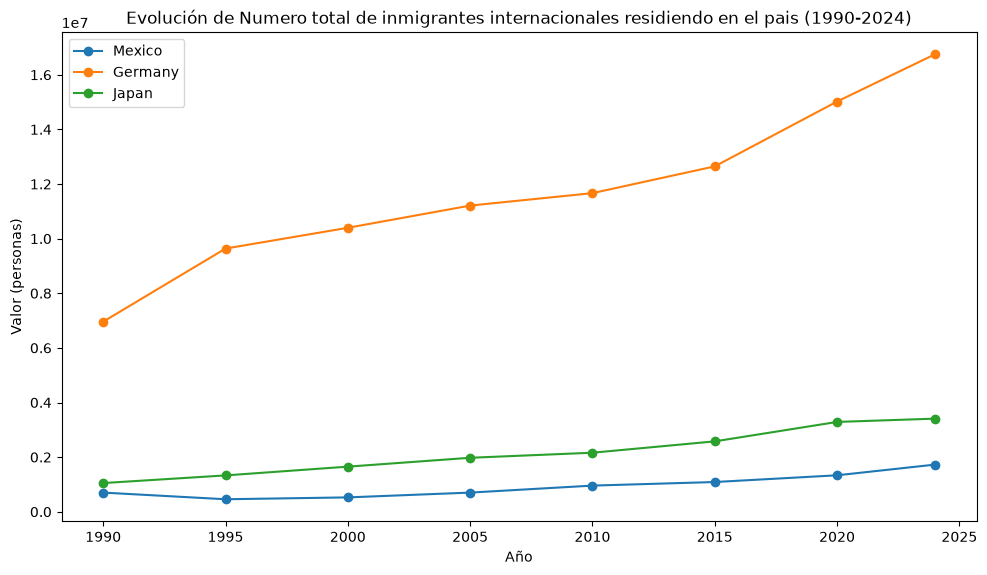

In [18]:
# Pregunta 8
# Tu codigo aqui
paises_8 = ["Mexico", "Germany", "Japan"]

plt.figure(figsize=(10, 6))
for pais in paises_8:
    sub_pais = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(sub_pais['year'], sub_pais['valor'], marker='o', label=pais)

plt.xlabel("Año")
plt.ylabel(f"Valor ({config['unidad']})")
plt.title(f"Evolución de {config['descripcion']} (1990-2024)")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación:**

Alemania muestra el crecimiento más marcado y constante de los tres países, casi triplicando su número de inmigrantes internacionales entre 1990 y 2024. Japón también mantiene una tendencia creciente pero mucho más moderada, mientras que México se mantiene en niveles muy inferiores a los otros dos países durante todo el periodo, aunque también muestra una tendencia al alza, especialmente después de 2010.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

Años disponibles en el dataset: [np.int64(1990), np.int64(1995), np.int64(2000), np.int64(2005), np.int64(2010), np.int64(2015), np.int64(2020), np.int64(2024)]
Año usado para mi año de nacimiento (2004): 2005
Año usado para 2023: 2024


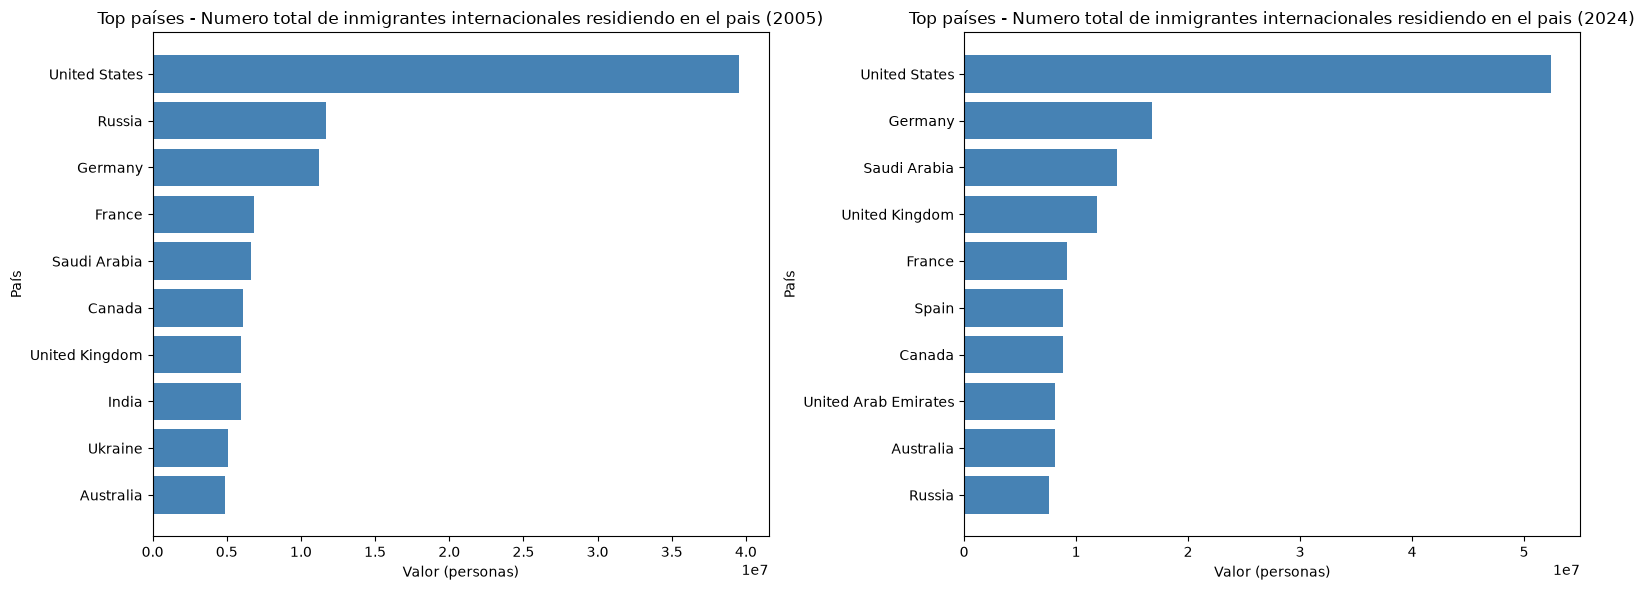

In [19]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

# El dataset solo tiene datos cada 5 anios (1990, 1995, ..., 2020, 2024),
# asi que usamos el anio disponible mas cercano a mi anio de nacimiento (2004)
# y el anio disponible mas cercano a 2023.
anio_nacimiento = 2004
anio_2023 = 2023
anios_disponibles = sorted(df_paises['year'].unique())

anio_consulta_1 = min(anios_disponibles, key=lambda y: abs(y - anio_nacimiento))
anio_consulta_2 = min(anios_disponibles, key=lambda y: abs(y - anio_2023))

print(f"Años disponibles en el dataset: {anios_disponibles}")
print(f"Año usado para mi año de nacimiento ({anio_nacimiento}): {anio_consulta_1}")
print(f"Año usado para 2023: {anio_consulta_2}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, anio_consultado in zip(axes, [anio_consulta_1, anio_consulta_2]):
    top = (
        df_paises[df_paises['year'] == anio_consultado]
        .sort_values('valor', ascending=False)
        .head(10)
    )
    ax.barh(top['entity'], top['valor'], color='steelblue')
    ax.set_xlabel(f"Valor ({config['unidad']})")
    ax.set_ylabel("País")
    ax.set_title(f"Top países - {config['descripcion']} ({anio_consultado})")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()


**Interpretación:**

Entre 2005 (año más cercano a mi nacimiento) y 2024, Estados Unidos se mantiene firmemente en el primer lugar y Alemania en el segundo, pero hay cambios notables en el resto de la lista: España y Emiratos Árabes Unidos entran al Top 10 en 2024, mientras que India y Ucrania salen de él. Esto refleja el fuerte crecimiento migratorio hacia España (impulsado por migración desde Latinoamérica) y hacia los países del Golfo Pérsico, así como una reducción relativa del número de inmigrantes en India y Ucrania (esta última afectada por el conflicto con Rusia).

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Trabajar con el dataset de migración de Our World in Data me permitió ver que el número de inmigrantes internacionales está altamente concentrado en un grupo pequeño de países de altos ingresos (Estados Unidos, Alemania, países del Golfo Pérsico), mientras que la mayoría de los países del mundo reciben cifras mucho más modestas. También noté que países como México y Colombia han transitado de ser predominantemente países de origen de migrantes a también convertirse en destinos migratorios relevantes.

La principal limitación de la información es que se trata de valores absolutos: un país con mucha población total (como India) puede tener un número de inmigrantes relativamente bajo simplemente porque son pocos en proporción a su población, y esta comparación absoluta no lo refleja.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
